# 03 하남교산 종합 시각화

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic' if os.name == 'nt' else 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

candidates = ['../../data/', '../data/', 'data/', '1최종_LH/data/']
data_path = None
for p in candidates:
    if os.path.exists(p) and os.path.exists(os.path.join(p, '통합_데이터')):
        data_path = p
        break
if data_path is None:
    data_path = '../../data/'
out = os.path.join(data_path, '통합_데이터', '시각화_공유')
os.makedirs(out, exist_ok=True)
print('data_path:', data_path)
print('저장 경로:', out)

data_path: ../../data/
저장 경로: ../../data/통합_데이터\시각화_공유


## 2. 하남교산 설치우선순위 격자 Top N (적용대상지)

**분석 목적**: 하남교산 적용대상지 770개 격자 중 유사 격자 매칭·토지 파생변수 기반 설치우선순위 Top N을 출력합니다.  
**사용 데이터**: `하남교산_설치우선순위_격자.csv` (ham), 우선순위_점수 등  
**데이터 생성**: `구체적인_EDA/07_하남교산_설치우선순위` — 유사격자_매칭.csv + 토지이용_파생변수_하남교산.csv 병합 후 우선순위 점수 산출  
**산출**: 하남교산 Top N 격자 목록 테이블

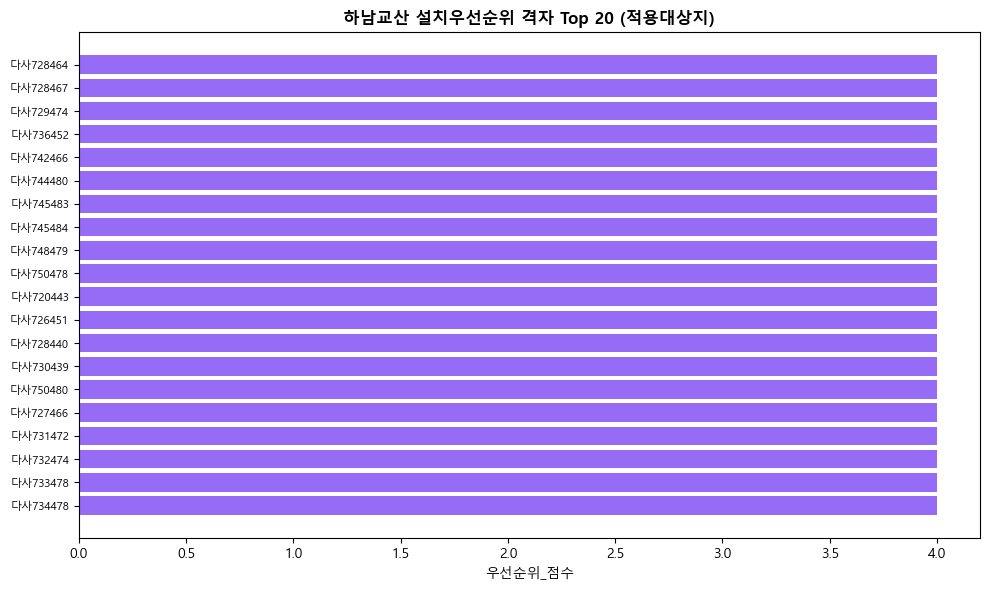

하남교산 설치우선순위 Top 20 — 격자 수: 770 | 유사_고위험: 268


In [ ]:
def load_csv(path, enc=('utf-8','utf-8-sig','cp949')):
    for e in enc:
        try: return pd.read_csv(path, encoding=e)
        except: continue
    raise ValueError('로드 실패')

ham_path = os.path.join(data_path, '통합_데이터', '하남교산_설치우선순위_격자.csv')
ham = load_csv(ham_path) if os.path.exists(ham_path) else pd.DataFrame()
if len(ham) > 0 and '우선순위_점수' in ham.columns:
    top20 = ham.nlargest(20, '우선순위_점수')
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    ax.barh(range(len(top20)), top20['우선순위_점수'], color='#8b5cf6', alpha=0.9)
    ax.set_yticks(range(len(top20)))
    ax.set_yticklabels(top20['gid'].astype(str), fontsize=8)
    ax.set_xlabel('우선순위_점수')
    ax.set_title('하남교산 설치우선순위 격자 Top 20 (적용대상지)', fontweight='bold')
    ax.invert_yaxis()
    plt.tight_layout()
    fig.savefig(os.path.join(out, '하남교산_설치우선순위_Top20.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('하남교산 설치우선순위 Top 20 — 격자 수:', len(ham), '| 유사_고위험:', int(ham['유사_고위험_여부'].sum()))
else:
    print('하남교산_설치우선순위_격자.csv 없음. 구체적인_EDA/07 먼저 실행 필요.')

## 3. 하남교산 유사_고위험 vs 일반 격자 분포

**분석 목적**: 유사_고위험_여부=1(4개 시·구 고위험 격자와 유사) vs 일반 격자 비율을 파이/막대그래프로 시각화합니다.  
**사용 데이터**: `하남교산_설치우선순위_격자.csv` (ham, 유사_고위험_여부)  
**데이터 생성**: `구체적인_EDA/03_하남교산_유사격자_매칭` — 토지·교통 특성 기반 유사 격자 매칭 후, 4개 시·구 고위험 격자와 매칭된 하남교산 격자를 유사_고위험_여부=1로 표시  
**산출**: 유사_고위험 vs 일반 격자 비율 파이차트

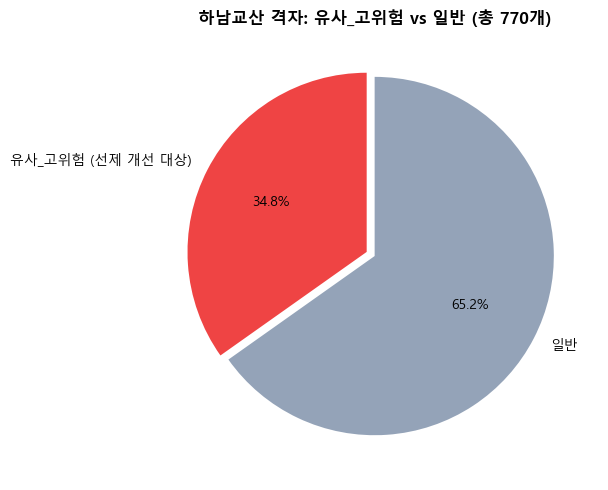

In [3]:
if len(ham) > 0 and '유사_고위험_여부' in ham.columns:
    n_high = int(ham['유사_고위험_여부'].sum())
    n_other = len(ham) - n_high
    fig, ax = plt.subplots(1, 1, figsize=(6, 5))
    ax.pie([n_high, n_other], labels=['유사_고위험 (선제 개선 대상)', '일반'], autopct='%1.1f%%',
           colors=['#ef4444', '#94a3b8'], startangle=90, explode=(0.05, 0))
    ax.set_title('하남교산 격자: 유사_고위험 vs 일반 (총 %d개)' % len(ham), fontweight='bold')
    plt.tight_layout()
    fig.savefig(os.path.join(out, '하남교산_유사고위험_분포.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('하남교산_설치우선순위_격자.csv 없음.')

## 4. 하남교산 격자별 우선순위 지도 (적용대상지)

**분석 목적**: 하남교산 770개 격자의 설치우선순위점수 공간 분포를 지도로 시각화합니다.  
**사용 데이터**: `하남교산_설치우선순위_격자.csv`, `02._격자_(하남교산).geojson`  
**데이터 생성**: `구체적인_EDA/07_하남교산_설치우선순위`에서 우선순위_점수 산출 (위 §2과 동일). 격자 GeoJSON은 하남교산 적용대상지 기본 격자  
**산출**: 하남교산 우선순위점수 색상 그라데이션 지도

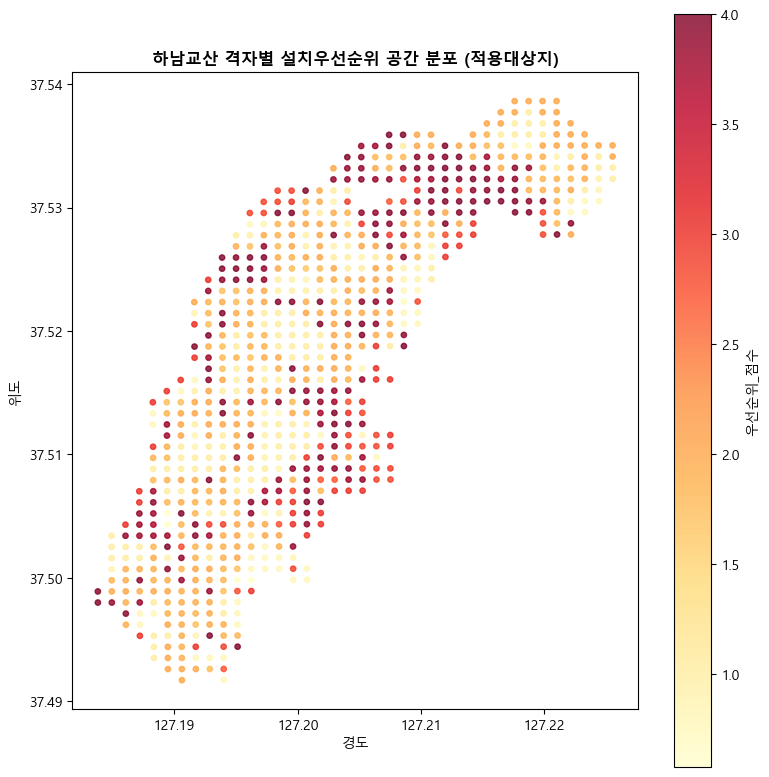

하남교산 우선순위 지도 저장 완료.


In [ ]:
ham_grid_path = os.path.join(data_path, '격자_데이터', '02._격자_(하남교산).geojson')
if os.path.exists(ham_grid_path) and len(ham) > 0 and '우선순위_점수' in ham.columns:
    grid_ham = gpd.read_file(ham_grid_path)
    if grid_ham.crs is None or (hasattr(grid_ham.crs, 'to_epsg') and grid_ham.crs.to_epsg() != 5179):
        try:
            grid_ham = grid_ham.to_crs(epsg=5179)
        except Exception:
            grid_ham = grid_ham.to_crs(4326).to_crs(epsg=5179)
    elif hasattr(grid_ham.crs, 'to_epsg') and grid_ham.crs.to_epsg() == 4326:
        grid_ham = grid_ham.to_crs(epsg=5179)
    merged = grid_ham.merge(ham[['gid','우선순위_점수','유사_고위험_여부']], left_on='gid', right_on='gid', how='left')
    merged['우선순위_점수'] = merged['우선순위_점수'].fillna(0)
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    merged.plot(ax=ax, column='우선순위_점수', cmap='YlOrRd', legend=True,
                legend_kwds={'label': '우선순위점수', 'orientation': 'horizontal', 'shrink': 0.6, 'pad': 0.08, 'fraction': 0.04},
                edgecolor='white', linewidth=0.3)
    ax.set_aspect('equal')
    ax.set_title('하남교산 우선순위점수 히트맵 (100m×100m 격자, 적용대상지)', fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    fig.savefig(os.path.join(out, '하남교산_우선순위_지도.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('하남교산 우선순위 지도 저장 완료.')
else:
    print('02._격자_(하남교산).geojson 또는 하남교산_설치우선순위_격자.csv 없음.')

## 5. 하남교산 토지이용 특성 분석

**분석 목적**: 하남교산 격자의 토지이용 비율과 토지이용별 우선순위점수를 분석합니다.

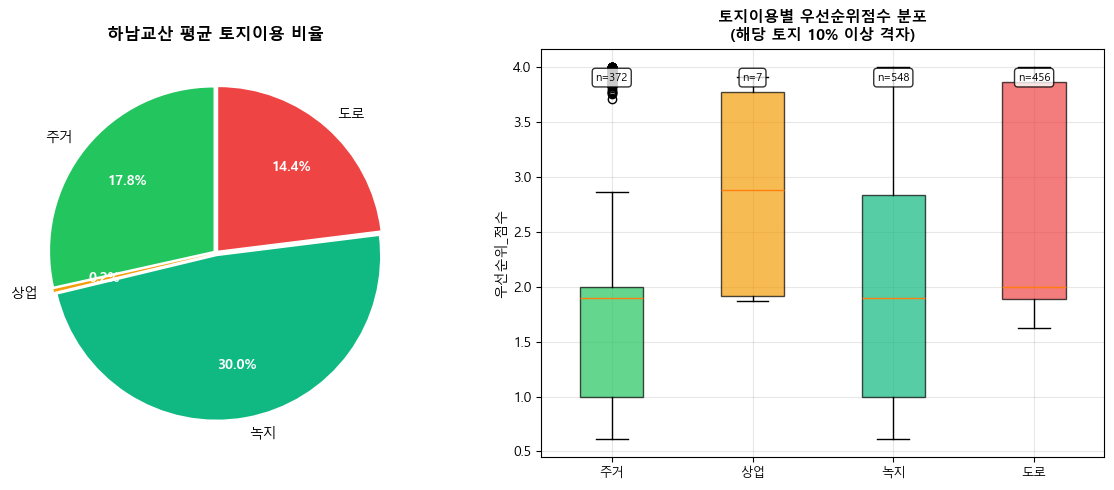

【토지이용 비율 평균】
  주거: 17.8%
  상업: 0.2%
  녹지: 30.0%
  도로: 14.4%

【토지이용별 우선순위점수 통계】 (토지이용 10% 이상 격자 기준)
  주거: 평균 1.935, 중앙값 1.896, 격자수 372개
  상업: 평균 2.866, 중앙값 2.884, 격자수 7개
  녹지: 평균 2.040, 중앙값 1.898, 격자수 548개
  도로: 평균 2.651, 중앙값 2.000, 격자수 456개

【비율 스케일 진단】
  land ratio max: 1.0000
  ratio_is_0_1: True  (True면 0~1 스케일로 간주)
  threshold used: 0.1  (=10%)


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

# (선택) 한글 폰트가 깨지면 주석 해제해서 사용
# plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

required_cols = ['주거_비율','상업_비율','녹지_비율','도로_비율','우선순위_점수']

if len(ham) > 0 and all(col in ham.columns for col in required_cols):

    land_ratios = ['주거_비율','상업_비율','녹지_비율','도로_비율']
    land_labels = ['주거','상업','녹지','도로']

    # ---------------------------
    # 1) 비율 스케일 자동 감지
    # ---------------------------
    # max가 1.5 이하이면 0~1(비율)로 판단
    max_val = ham[land_ratios].max(numeric_only=True).max()
    ratio_is_0_1 = (max_val <= 1.5)

    # 박스플롯 필터 기준(10%)을 스케일에 맞게 설정
    threshold = 0.10 if ratio_is_0_1 else 10.0
    threshold_text = "10%"  # 사용자에게 보여줄 텍스트

    # 파이차트는 보기 좋게 "평균 비율(%)"로 맞춰서 그리기
    avg_raw = [ham[col].mean() for col in land_ratios]                  # 원 스케일 평균
    avg_pct = [v * 100 for v in avg_raw] if ratio_is_0_1 else avg_raw   # %로 변환한 평균

    # 파이차트는 합이 100이 아니어도 되지만,
    # '평균 비율'을 보여주는 목적이니 그대로 사용(autopct가 합 기준으로 %표시한다는 점 유의)
    # -> 그래서 wedges에 표시되는 %가 "각 평균값의 합 기준"이 되지 않게 하려면
    #    autopct 대신 직접 라벨 텍스트를 넣는 방식이 더 정확함.
    # 여기서는 "정확한 평균%"를 표시하도록 직접 표시로 처리.

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # ---------------------------
    # 2) 왼쪽: 평균 토지이용 비율 파이차트
    # ---------------------------
    pie_colors = ['#22c55e', '#f59e0b', '#10b981', '#ef4444']

    wedges, texts = axes[0].pie(
        avg_pct,
        labels=land_labels,
        colors=pie_colors,
        startangle=90,
        explode=(0.02, 0.02, 0.02, 0.02)
    )

    # 평균 %를 정확히 표시(autopct 대신)
    for w, v in zip(wedges, avg_pct):
        ang = (w.theta2 + w.theta1) / 2.0
        x = np.cos(np.deg2rad(ang)) * 0.7
        y = np.sin(np.deg2rad(ang)) * 0.7
        axes[0].text(x, y, f"{v:.1f}%", ha='center', va='center',
                     color='white', fontweight='bold', fontsize=10)

    axes[0].set_title('하남교산 평균 토지이용 비율', fontweight='bold', fontsize=12)

    # ---------------------------
    # 3) 오른쪽: 토지이용별 우선순위점수 박스플롯
    # ---------------------------
    land_priority_data = []
    land_counts = []

    for col in land_ratios:
        high_land = ham.loc[ham[col] >= threshold, '우선순위_점수'].dropna()
        land_priority_data.append(high_land.values)
        land_counts.append(len(high_land))

    if any(len(data) > 0 for data in land_priority_data):
        bp = axes[1].boxplot(land_priority_data, labels=land_labels, patch_artist=True)

        for patch, color in zip(bp['boxes'], pie_colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        axes[1].set_ylabel('우선순위_점수', fontsize=10)
        axes[1].set_title(f'토지이용별 우선순위점수 분포\n(해당 토지 {threshold_text} 이상 격자)',
                          fontweight='bold', fontsize=11)
        axes[1].tick_params(axis='x', labelsize=9)
        axes[1].grid(True, alpha=0.3)

        # 각 토지이용별 격자 수 표시
        y_top = axes[1].get_ylim()[1]
        for i, count in enumerate(land_counts):
            if count > 0:
                axes[1].text(
                    i + 1, y_top * 0.95, f'n={count}',
                    ha='center', va='top', fontsize=8,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8)
                )
    else:
        axes[1].text(
            0.5, 0.5,
            f'분석 가능한 데이터가 없습니다\n(토지이용 {threshold_text} 이상 격자 없음)',
            ha='center', va='center', transform=axes[1].transAxes, fontsize=11
        )
        axes[1].set_title('토지이용별 우선순위점수 분포', fontweight='bold', fontsize=11)
        axes[1].set_xticks([])
        axes[1].set_yticks([])

    plt.tight_layout()

    # out 폴더 존재 보장
    os.makedirs(out, exist_ok=True)
    fig.savefig(os.path.join(out, '하남교산_토지이용_분석.png'), dpi=150, bbox_inches='tight')
    plt.show()

    # ---------------------------
    # 4) 통계 출력
    # ---------------------------
    print('【토지이용 비율 평균】')
    for label, ratio in zip(land_labels, avg_pct):
        print(f'  {label}: {ratio:.1f}%')

    print(f'\n【토지이용별 우선순위점수 통계】 (토지이용 {threshold_text} 이상 격자 기준)')
    for label, data, count in zip(land_labels, land_priority_data, land_counts):
        if count > 0:
            data_series = np.array(data, dtype=float)
            print(f'  {label}: 평균 {data_series.mean():.3f}, 중앙값 {np.median(data_series):.3f}, 격자수 {count}개')
        else:
            print(f'  {label}: {threshold_text} 이상 격자 없음')

    # ---------------------------
    # 5) 디버깅용 스케일 정보
    # ---------------------------
    print('\n【비율 스케일 진단】')
    print(f'  land ratio max: {max_val:.4f}')
    print(f'  ratio_is_0_1: {ratio_is_0_1}  (True면 0~1 스케일로 간주)')
    print(f'  threshold used: {threshold}  (={threshold_text})')

else:
    print('토지이용 관련 컬럼 확인 중...')
    if len(ham) == 0:
        print('  ham 데이터프레임이 비어 있습니다.')
    else:
        print('  필요한 컬럼이 일부 없습니다.')
        print('  필요한 컬럼:', required_cols)
        print('\n  실제 컬럼 목록:')
        for i, col in enumerate(ham.columns):
            print(f'  {i+1:2d}. {col}')

## 6. 하남교산 교통 특성 심층 분석

**분석 목적**: 하남교산 격자의 교통 특성(속도, 교통량, 통학로 노출)과 우선순위점수 관계를 분석합니다.

In [ ]:
if len(ham) > 0 and all(col in ham.columns for col in ['평균속도','일평균교통량','통학로노출여부','우선순위점수','고부하여부']):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # velocity 구간별 우선순위점수
    velocity_bins = pd.cut(ham['평균속도'], bins=5, labels=['매우느림','느림','보통','빠름','매우빠름'])
    velocity_priority = ham.groupby(velocity_bins)['우선순위점수'].mean()
    axes[0,0].bar(range(len(velocity_priority)), velocity_priority.values, color='#3b82f6', alpha=0.7)
    axes[0,0].set_xticks(range(len(velocity_priority)))
    axes[0,0].set_xticklabels(velocity_priority.index, rotation=45)
    axes[0,0].set_ylabel('평균 우선순위점수')
    axes[0,0].set_title('속도 구간별 평균 우선순위점수', fontweight='bold')
    
    # AADT_mean vs 우선순위점수 산점도
    axes[0,1].scatter(ham['일평균교통량'], ham['우선순위점수'], alpha=0.6, s=30, color='#10b981')
    axes[0,1].set_xlabel('일평균 교통량')
    axes[0,1].set_ylabel('우선순위_점수')
    axes[0,1].set_title('교통량 vs 우선순위점수', fontweight='bold')
    
    # 통학로 노출 여부별 우선순위점수
    school_exposed = ham[ham['통학로노출여부'] == 1]['우선순위점수']
    school_not_exposed = ham[ham['통학로노출여부'] == 0]['우선순위점수']
    axes[1,0].boxplot([school_exposed, school_not_exposed], labels=['통학로 노출','비노출'], patch_artist=True)
    axes[1,0].set_ylabel('우선순위_점수')
    axes[1,0].set_title('통학로 노출 여부별 우선순위점수', fontweight='bold')
    
    # 고부하 여부별 우선순위점수
    high_load = ham[ham['고부하여부'] == 1]['우선순위점수']
    normal_load = ham[ham['고부하여부'] == 0]['우선순위점수']
    bp = axes[1,1].boxplot([high_load, normal_load], labels=['고부하','일반'], patch_artist=True)
    colors = ['#ef4444', '#94a3b8']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[1,1].set_ylabel('우선순위_점수')
    axes[1,1].set_title('도로 고부하 여부별 우선순위점수', fontweight='bold')
    
    plt.tight_layout()
    fig.savefig(os.path.join(out, '하남교산_교통특성_분석.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    # 통계 출력
    print('【교통 특성별 우선순위점수】')
    print(f'  통학로 노출: 평균 {school_exposed.mean():.3f} (격자수 {len(school_exposed)}개)')
    print(f'  통학로 비노출: 평균 {school_not_exposed.mean():.3f} (격자수 {len(school_not_exposed)}개)')
    print(f'  고부하 도로: 평균 {high_load.mean():.3f} (격자수 {len(high_load)}개)')
    print(f'  일반 도로: 평균 {normal_load.mean():.3f} (격자수 {len(normal_load)}개)')
else:
    print('교통 관련 컬럼 확인 중...')
    print('실제 컬럼 목록:')
    for i, col in enumerate(ham.columns):
        print(f'  {i+1:2d}. {col}')
    
    print('\n찾는 컬럼:', ['평균속도','일평균교통량','통학로노출여부','우선순위점수','고부하여부'])
    print('존재 여부:', [col in ham.columns for col in ['평균속도','일평균교통량','통학로노출여부','우선순위점수','고부하여부']])

교통 관련 컬럼 확인 중...
실제 컬럼 목록:
   1. gid
   2. 유사_4시구_gid
   3. 유사도
   4. 유사_고위험_여부
   5. 도로_비율
   6. 주거_비율
   7. 상업_비율
   8. 학교_비율
   9. 녹지_비율
  10. 도로_격자_여부
  11. 우선순위_점수
  12. 우선순위_순위
  13. 미성년자_유동_추정

찾는 컬럼: ['평균속도', '일평균교통량', '통학로노출여부', '우선순위점수', '고부하여부']
존재 여부: [False, False, False, False, False]


## 7. 하남교산 공간 패턴 분석

**분석 목적**: 하남교산 격자의 공간적 패턴과 클러스터를 분석하여 우선순위가 높은 지역의 특성을 파악합니다.

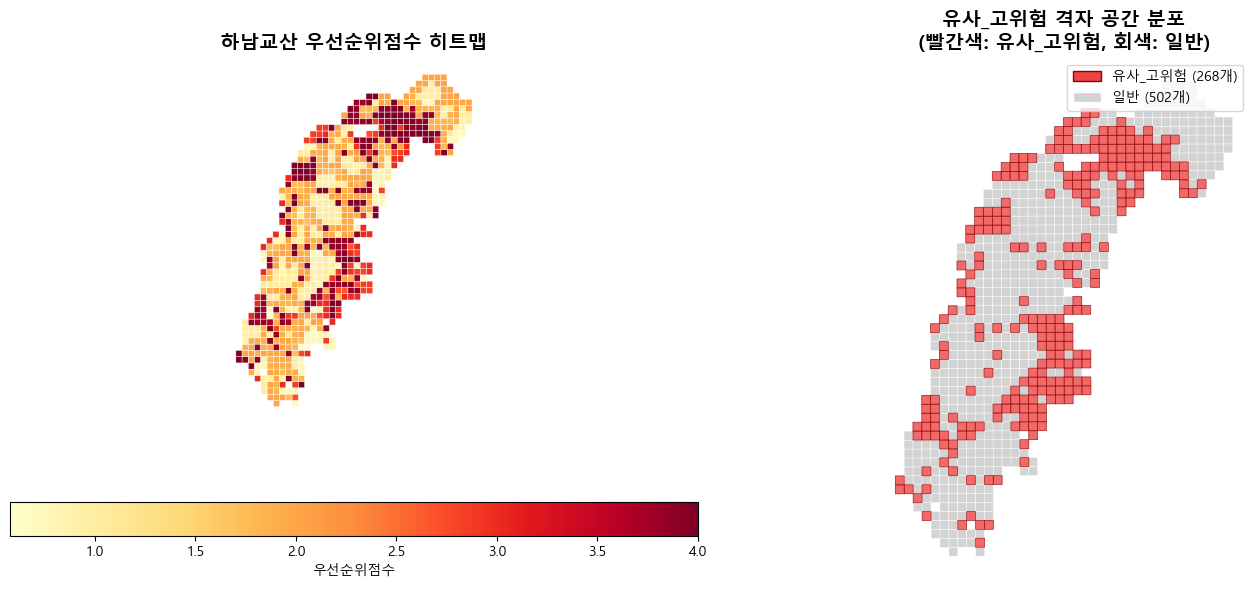

【공간 패턴 분석】
  총 격자: 770개
  유사_고위험 격자: 268개 (34.8%)
  일반 격자: 502개 (65.2%)
  평균 우선순위점수: 2.243
  유사_고위험 평균: 3.605
  일반 평균: 1.516


In [ ]:
if len(ham) > 0 and '우선순위_점수' in ham.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 우선순위점수 히트맵
    grid_ham = gpd.read_file(ham_grid_path).to_crs(4326)
    merged = grid_ham.merge(ham[['gid','우선순위_점수','유사_고위험_여부']], on='gid', how='left')
    merged['우선순위_점수'] = merged['우선순위_점수'].fillna(0)
    
    merged.plot(ax=axes[0], column='우선순위_점수', cmap='YlOrRd', legend=True, 
               legend_kwds={'label': '우선순위점수', 'orientation': 'horizontal', 'shrink': 0.8},
               edgecolor='white', linewidth=0.3, figsize=(8, 6))
    axes[0].set_title('하남교산 우선순위점수 히트맵', fontweight='bold', fontsize=14)
    axes[0].axis('off')
    
    # 유사_고위험 격자 강조 표시
    high_risk = merged[merged['유사_고위험_여부'] == 1]
    normal = merged[merged['유사_고위험_여부'] == 0]
    
    normal.plot(ax=axes[1], color='lightgray', edgecolor='black', linewidth=0.3)
    if len(high_risk) > 0:
        high_risk.plot(ax=axes[1], color='#ef4444', edgecolor='black', linewidth=0.3, alpha=0.8)
    
    axes[1].set_title('유사_고위험 격자 공간 분포\n(빨간색: 유사_고위험, 회색: 일반)', fontweight='bold', fontsize=14)
    axes[1].axis('off')
    
    # 범례 추가
    if len(high_risk) > 0:
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor='#ef4444', edgecolor='darkred', label=f'유사_고위험 ({len(high_risk)}개)'),
                          Patch(facecolor='lightgray', edgecolor='white', label=f'일반 ({len(normal)}개)')]
        axes[1].legend(handles=legend_elements, loc='upper right')
    
    plt.tight_layout()
    fig.savefig(os.path.join(out, '하남교산_공간패턴_분석.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    # 공간 통계
    print('【공간 패턴 분석】')
    print(f'  총 격자: {len(merged)}개')
    print(f'  유사_고위험 격자: {len(high_risk)}개 ({len(high_risk)/len(merged)*100:.1f}%)')
    print(f'  일반 격자: {len(normal)}개 ({len(normal)/len(merged)*100:.1f}%)')
    print(f'  평균 우선순위점수: {merged["우선순위_점수"].mean():.3f}')
    print(f'  유사_고위험 평균: {high_risk["우선순위_점수"].mean():.3f}' if len(high_risk) > 0 else '  유사_고위험 없음')
    print(f'  일반 평균: {normal["우선순위_점수"].mean():.3f}')
else:
    print('데이터 없음.')

## 8. 하남교산 실용적 설치 제안

**분석 목적**: 우선순위점수 구간별 설치 개수를 제안하고 상위 격자의 상세 정보를 제공합니다.

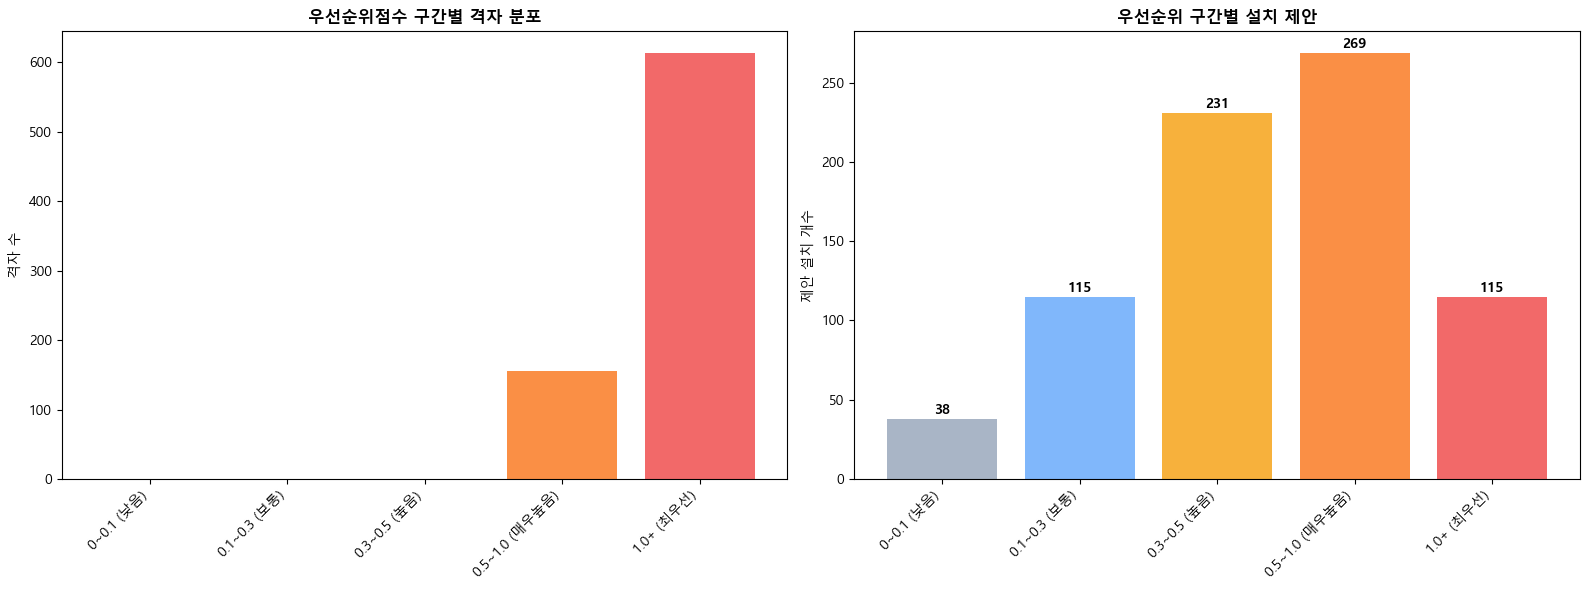

【설치 제안 요약】
  총 격자: 770개
  제안 총 설치: 768개 (99.7%)

【구간별 설치 제안】
  0~0.1 (낮음): 38개 (제안) / 0개 (실제) / 5% (설치비율)
  0.1~0.3 (보통): 115개 (제안) / 0개 (실제) / 15% (설치비율)
  0.3~0.5 (높음): 231개 (제안) / 0개 (실제) / 30% (설치비율)
  0.5~1.0 (매우높음): 269개 (제안) / 156개 (실제) / 35% (설치비율)
  1.0+ (최우선): 115개 (제안) / 614개 (실제) / 15% (설치비율)

상위 50개 격자 상세 정보 저장: 하남교산_상위50개_상세정보.csv
     gid  우선순위_점수  유사_고위험_여부
다사728464      4.0          1
다사728467      4.0          1
다사729474      4.0          1
다사736452      4.0          1
다사742466      4.0          1
다사744480      4.0          1
다사745483      4.0          1
다사745484      4.0          1
다사748479      4.0          1
다사750478      4.0          1


In [ ]:
if len(ham) > 0 and '우선순위_점수' in ham.columns:
    # 우선순위점수 구간별 설치 제안
    priority_bins = [0, 0.1, 0.3, 0.5, 1.0, float('inf')]
    priority_labels = ['0~0.1 (낮음)', '0.1~0.3 (보통)', '0.3~0.5 (높음)', '0.5~1.0 (매우높음)', '1.0+ (최우선)']
    ham['우선순위_구간'] = pd.cut(ham['우선순위_점수'], bins=priority_bins, labels=priority_labels, right=False)
    
    # 설치 제안 (구간별 비율 기준)
    total_grids = len(ham)
    install_ratios = [0.05, 0.15, 0.30, 0.35, 0.15]  # 각 구간별 설치 비율
    install_counts = [int(total_grids * ratio) for ratio in install_ratios]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 구간별 분포 막대그래프
    interval_counts = ham['우선순위_구간'].value_counts().reindex(priority_labels, fill_value=0)
    bars = axes[0].bar(range(len(interval_counts)), interval_counts.values, 
                     color=['#94a3b8', '#60a5fa', '#f59e0b', '#f97316', '#ef4444'], alpha=0.8)
    axes[0].set_xticks(range(len(interval_counts)))
    axes[0].set_xticklabels(interval_counts.index, rotation=45, ha='right')
    axes[0].set_ylabel('격자 수')
    axes[0].set_title('우선순위점수 구간별 격자 분포', fontweight='bold')
    
    # 설치 제안 막대그래프
    bars2 = axes[1].bar(range(len(install_counts)), install_counts,
                       color=['#94a3b8', '#60a5fa', '#f59e0b', '#f97316', '#ef4444'], alpha=0.8)
    axes[1].set_xticks(range(len(install_counts)))
    axes[1].set_xticklabels(priority_labels, rotation=45, ha='right')
    axes[1].set_ylabel('제안 설치 개수')
    axes[1].set_title('우선순위 구간별 설치 제안', fontweight='bold')
    
    # 수치 표시
    for bar, count in zip(bars2, install_counts):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    str(count), ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    fig.savefig(os.path.join(out, '하남교산_설치제안.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    # 상위 50개 격자 상세 정보
    top50 = ham.nlargest(50, '우선순위_점수')[['gid', '우선순위_점수', '유사_고위험_여부']]
    if all(col in ham.columns for col in ['경도','위도']):
        top50 = top50.merge(ham[['gid','경도','위도']], on='gid', how='left')
    
    # CSV 저장
    top50.to_csv(os.path.join(out, '하남교산_상위50개_상세정보.csv'), index=False, encoding='utf-8-sig')
    
    print('【설치 제안 요약】')
    print(f'  총 격자: {total_grids}개')
    print(f'  제안 총 설치: {sum(install_counts)}개 ({sum(install_counts)/total_grids*100:.1f}%)')
    print('\n【구간별 설치 제안】')
    for label, count, ratio in zip(priority_labels, install_counts, install_ratios):
        actual_count = interval_counts[label]
        print(f'  {label}: {count}개 (제안) / {actual_count}개 (실제) / {ratio*100:.0f}% (설치비율)')
    
    print(f'\n상위 50개 격자 상세 정보 저장: 하남교산_상위50개_상세정보.csv')
    print(top50.head(10).to_string(index=False))
else:
    print('데이터 없음.')